In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("fraud_detection_dataset_2000_rows.csv")
df

,transaction_amount,transactions_last_24h,account_age_days,distance_from_home_km,is_foreign_transaction,is_high_risk_country,fraud
0,56.31,3,1208,29.88,0,0,0
1,361.21,4,471,6.97,0,0,1
2,158.01,1,1340,3.51,0,0,1
3,109.55,2,1621,22.38,0,0,1
4,20.35,4,254,8.51,0,0,1
...,...,...,...,...,...,...,...
1995,128.39,3,106,6.66,0,1,1
1996,376.52,2,239,8.71,1,0,1
1997,8.57,3,236,10.99,0,0,1
1998,7.05,2,380,14.99,0,0,1


In [7]:
import matplotlib.pyplot as plt

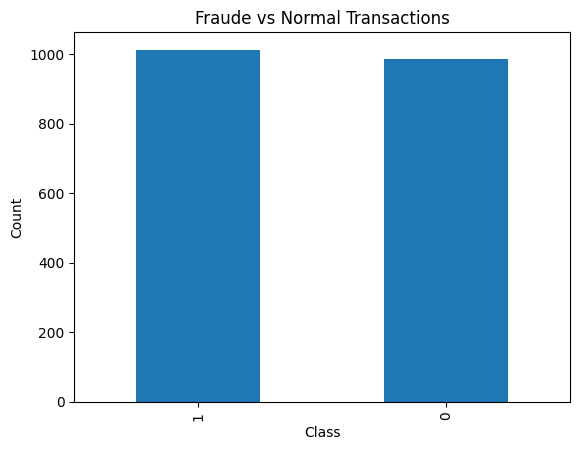

In [8]:
df["fraud"].value_counts().plot(kind="bar")
plt.title("Fraude vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [9]:
X=df.drop("fraud",axis=1)
y=df["fraud"]

In [10]:
from sklearn.model_selection import train_test_split

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [20]:
y_prob = model.predict_proba(X_test)[:,1]

In [26]:
from sklearn.metrics import accuracy_score,confusion_matrix, roc_curve, roc_auc_score

In [24]:
accuracy_score(y_test,y_pred)

0.62

In [25]:
confusion_matrix(y_test,y_pred)

array([[122,  80],
       [ 72, 126]])

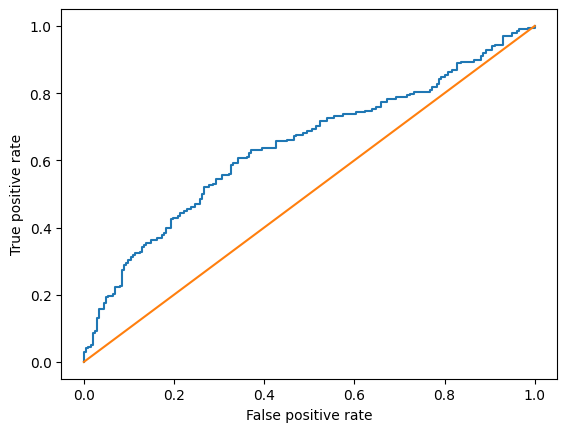

In [27]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.show()

In [28]:
roc_auc_score(y_test,y_prob)

0.6413391339133913

In [32]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Weight": model.coef_[0]
})

print(importance)

                  Feature    Weight
0      transaction_amount  0.002994
1   transactions_last_24h  0.109677
2        account_age_days -0.000469
3   distance_from_home_km  0.004477
4  is_foreign_transaction  0.389598
5    is_high_risk_country  0.715902
